In [7]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from sklearn import datasets


In [2]:
iris = datasets.load_iris()
iris_data = pd.DataFrame(iris.data)
iris_data.columns = iris.feature_names
iris_data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [17]:
pca_scaled = scaler.fit_transform(iris_data)
pca_scaled

array([[-9.00681170e-01,  1.01900435e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00, -1.31979479e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.38535265e+00,  3.28414053e-01, -1.39706395e+00,
        -1.31544430e+00],
       [-1.50652052e+00,  9.82172869e-02, -1.28338910e+00,
        -1.31544430e+00],
       [-1.02184904e+00,  1.24920112e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-5.37177559e-01,  1.93979142e+00, -1.16971425e+00,
        -1.05217993e+00],
       [-1.50652052e+00,  7.88807586e-01, -1.34022653e+00,
        -1.18381211e+00],
       [-1.02184904e+00,  7.88807586e-01, -1.28338910e+00,
        -1.31544430e+00],
       [-1.74885626e+00, -3.62176246e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00,  9.82172869e-02, -1.28338910e+00,
        -1.44707648e+00],
       [-5.37177559e-01,  1.47939788e+00, -1.28338910e+00,
        -1.31544430e+00],
       [-1.26418478e+00,  7.88807586e-01, -1.22655167e+00,
      

In [18]:
pca_scaled.shape


(150, 4)

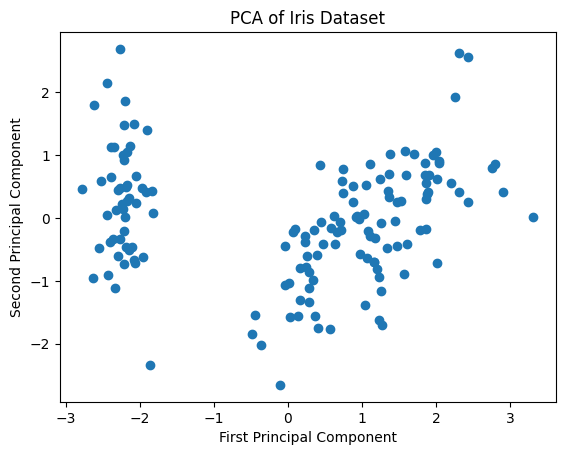

In [19]:
# apply pca 
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_scale = pca.fit_transform(pca_scaled)
plt.scatter(pca_scale[:,0], pca_scale[:,1])
plt.xlabel('First Principal Component') 
plt.ylabel('Second Principal Component')
plt.title('PCA of Iris Dataset')
plt.show()


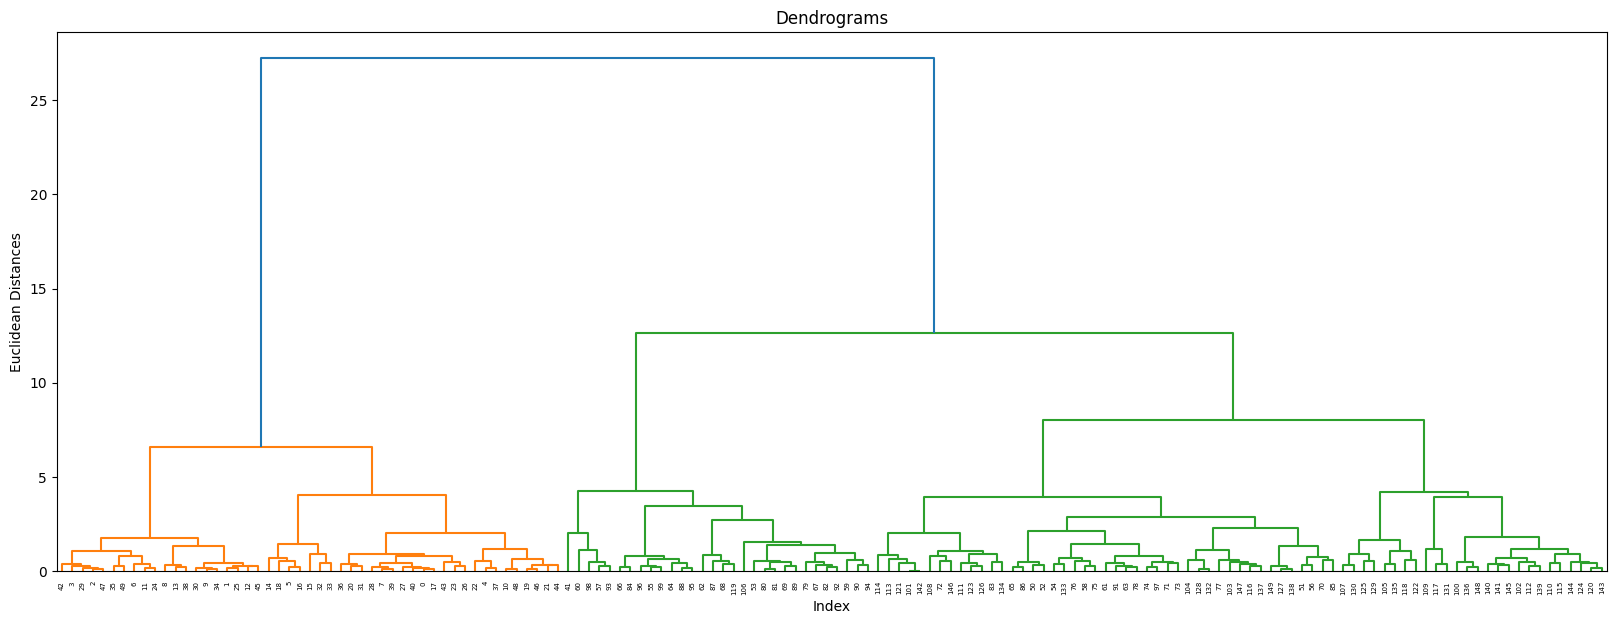

In [20]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering 
plt.figure(figsize=(20,7))  
plt.title("Dendrograms")  
sch.dendrogram(sch.linkage(pca_scaled, method='ward'))
plt.xlabel("Index")
plt.ylabel("Euclidean Distances")
plt.show()  

In [24]:
from sklearn.cluster import AgglomerativeClustering

# Create the clustering model (using metric instead of affinity)
cluster = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')

# Fit the model on your PCA-transformed data
cluster.fit(pca_scaled)

# Get cluster labels
labels = cluster.labels_

print(labels)


[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


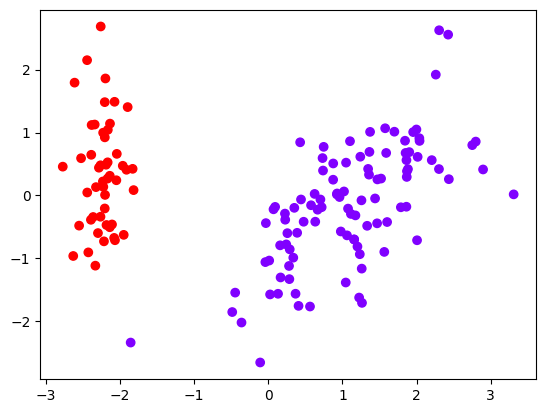

In [25]:
cluster.labels_
plt.scatter(pca_scale[:,0], pca_scale[:,1], c=cluster.labels_, cmap='rainbow')

In [26]:
from sklearn.metrics import silhouette_score


In [28]:
silhouette_coefficient = []
for k in range(2, 10):
    cluster = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    cluster.fit(pca_scaled)
    score = silhouette_score(pca_scaled, cluster.labels_)
    silhouette_coefficient.append(score)

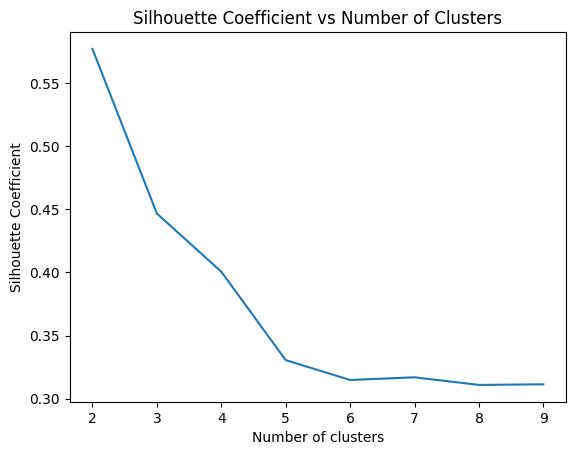

In [29]:
plt.plot(range(2,10), silhouette_coefficient)
plt.title('Silhouette Coefficient vs Number of Clusters')           
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Coefficient')
plt.show()